# Modelo Boosting 

In [22]:
# Librerias 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [23]:
# 1. Cargar los datos 
X_train_sel = pd.read_csv("clean_dataset_train.csv")
X_test_sel = pd.read_csv("clean_dataset_test.csv")


In [24]:
# 2. Separar X e y 
y_train = X_train_sel["Outcome"]
X_train = X_train_sel.drop("Outcome", axis=1)

y_test = X_test_sel["Outcome"]
X_test = X_test_sel.drop("Outcome", axis=1)

In [ ]:
# 3. Crear el modelo Boosting 
gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)

In [ ]:
# 4. Entrenar
gb.fit(X_train, y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [ ]:
# 5. Predicciones
y_pred = gb.predict(X_test)

In [ ]:
# 6. Métricas 
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, output_dict=True)
conf_matrix = confusion_matrix(y_test, y_pred)

C:\Users\7sean\AppData\Local\Temp\ipykernel_10452\3975417887.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_df, x="Importance", y="Feature", palette="mako")


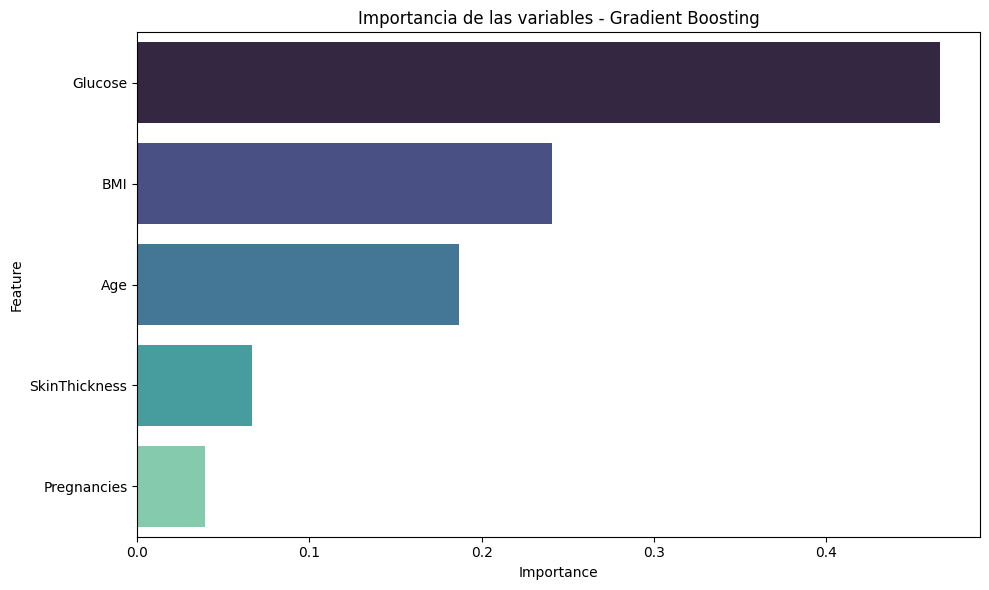

In [ ]:
# 7. Visualizaciones 
# Importancia de las variables
importances = gb.feature_importances_
features = X_train.columns
feature_df = pd.DataFrame({"Feature": features, "Importance": importances})
feature_df = feature_df.sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_df, x="Importance", y="Feature", palette="mako")
plt.title("Importancia de las variables - Gradient Boosting")
plt.tight_layout()
plt.show()

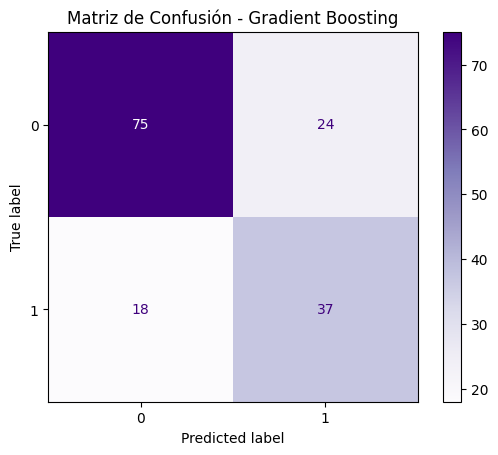

In [30]:
# Matriz de confusión
ConfusionMatrixDisplay.from_estimator(gb, X_test, y_test, cmap="Purples")
plt.title("Matriz de Confusión - Gradient Boosting")
plt.show()

In [31]:
# Mostrar resultados directamente 
accuracy, pd.DataFrame(report).T, pd.DataFrame(conf_matrix)

(0.7272727272727273,
               precision    recall  f1-score     support
 0              0.806452  0.757576  0.781250   99.000000
 1              0.606557  0.672727  0.637931   55.000000
 accuracy       0.727273  0.727273  0.727273    0.727273
 macro avg      0.706504  0.715152  0.709591  154.000000
 weighted avg   0.735061  0.727273  0.730065  154.000000,
     0   1
 0  75  24
 1  18  37)

El modelo de Gradient Boosting 

- Se logró una precisión global del 72.7%, lo que indica un desempeño aceptable en la clasificación de pacientes con y sin diabetes.

- Al analizar los resultados, se observa que el modelo es más efectivo identificando a los pacientes no diabéticos, con una precisión del 80.6% y una sensibilidad del 75.8%. Esto significa que, en la mayoría de los casos, clasifica correctamente a quienes no presentan la enfermedad.

- En el caso de los pacientes con diagnóstico positivo de diabetes, el modelo presenta una precisión del 60.7% y una sensibilidad del 67.3%. Esto indica que aproximadamente 2 de cada 3 pacientes con diabetes son correctamente identificados, aunque hay un margen importante de error, especialmente en predicciones positivas incorrectas. Se registraron 18 falsos negativos, es decir, pacientes con diabetes que el modelo no detectó.

- Desde el punto de vista de la salud, estos errores pueden tener implicaciones serias, ya que podrían retrasar diagnósticos o tratamientos necesarios. Por tanto, aunque el modelo puede ser útil como herramienta de apoyo, no debería utilizarse como único criterio de diagnóstico, sino como un complemento a la evaluación clínica.

